In [26]:
import pandas as pd
from pandas import ExcelWriter, ExcelFile
import numpy as np
import matplotlib.pyplot as plt

In [27]:
#  Celda 2: Utilidades estadísticas y configuración del entorno
from pathlib import Path
from dataclasses import dataclass # Para crear estructuras de datos simples
from typing import Tuple, List, Optional

# importa las funciones necesarias
from scipy.stats import anderson, t # Pruebas estadísticas AD y t de Student

# Configuración visual mínima de gráficos
plt.rcParams["figure.figsize"] = (8, 4.5) #define tamaño base
plt.rcParams["axes.grid"] = True #activa grid

# Directorio de salida para las figuras
#para mantener el orden según lo solicitado
OUT_DIR = Path("Documentacion/Avance 1/figures") #evita que las figuras se mezclen con código u otros avances
OUT_DIR.mkdir(parents=True, exist_ok=True)

#Estructura de datos para resultados de la prueba AD
@dataclass # agrupa los resultados de la prueba de Anderson–Darling
class ADResult: # mantiene toda la info del test agrupada en un solo objeto
    statistic: float #valor A^2
    crit_values: np.ndarray #valores críticos para distintos niveles de significancia
    sig_levels: np.ndarray #niveles  de significancia: 1%, 2.5%, 5%, 10%, 15%
    decision_alpha_5: bool   # true si no se rechaza la normalidad a α=0.05

# ejecuta la prueba de Anderson–Darling para verificar la normalidad
# de un conjunto de datos numéricos
def anderson_normal_test(x: np.ndarray, alpha: float = 0.05) -> ADResult:
    res = anderson(x, dist='norm') # ejecuta prueba A–D sobre los datos
    # En SciPy no viene p-value directo, comparamos contra el crítico más cercano a alpha
    idx = (np.abs(res.significance_level/100 - alpha)).argmin()
    crit = res.critical_values[idx]
    decision = res.statistic < crit  # true si los datos son compatibles con normalidad
    return ADResult(res.statistic, res.critical_values, res.significance_level, decision)

def basic_stats(x: np.ndarray) -> dict: #calcula los principales estadísticos descriptivos de un vector x
    return {
        "n": x.size, #tamaño muestral 
        "mean": float(np.mean(x)), #media
        "std": float(np.std(x, ddof=1)), #desv. estándar muestral
        "min": float(np.min(x)), #valor mínimo
        "q1": float(np.quantile(x, 0.25)), #primer cuartil
        "median": float(np.median(x)), #mediana
        "q3": float(np.quantile(x, 0.75)), #tercer cuartil
        "max": float(np.max(x)), #valor máx
    }

In [28]:
# carga del conjutno de datos para convertirlo en un formato numérico maneajable (numpy)
DATA_PATH = Path("Dataset.xlsx")  #objeto PATH que apunta al archivo excel
COLUMN    = "BPM"                 
                   
df = pd.read_excel(DATA_PATH) #lectura del excel

x = df[COLUMN].dropna().to_numpy(dtype=float) #conversión de datos

print(f"Archivo: {DATA_PATH.resolve()}") #muestra la ruta

Archivo: C:\Users\kenda\OneDrive\Documents\TEC\IIS2025\Taller de comu\ProyectoFinal\Grupo2_TCE\Jupyter\Dataset.xlsx


In [29]:
#analisis estadístico inicial antes de aplicar filtros
stats = basic_stats(x) #funcion definida en la celda 1, se les carga el vector x
stats #calcula y devuelve el diccionario
print("Estadística descriptiva:") #presentación de resultados numéricos
for k in ["n","mean","std","min","q1","median","q3","max"]:
    print(f"{k:>7}: {stats[k]:.3f}" if k!="n" else f"{k:>7}: {stats[k]}")
#prueba AD
alpha = 0.05 # nivel de significancia (5%) equivalente a un 95% de confianza
ad = anderson_normal_test(x, alpha=alpha)  # ejecuta la prueba sobre el vector de datos
# resultados principales del test
print(f"\n Anderson–Darling (normal):")
print(f"  Estadístico A^2: {ad.statistic:.4f}")
#tabla de niveles de significancia y valores críticos
for sl, cv in zip(ad.sig_levels, ad.crit_values):
    print(f"  Nivel {sl:>5.1f}%  →  Crítico {cv:.4f}")

if ad.decision_alpha_5:
    print(f"\n Decisión (α={alpha}): NO se rechaza H0. Los datos provienen de una distribución normal.")
else:
    print(f"\n Decisión (α={alpha}): Se rechaza H0 (NO normal).")
    


Estadística descriptiva:
      n: 127
   mean: 129.155
    std: 19.727
    min: 90.436
     q1: 114.678
 median: 128.714
     q3: 143.593
    max: 164.849

 Anderson–Darling (normal):
  Estadístico A^2: 0.5773
  Nivel  15.0%  →  Crítico 0.5590
  Nivel  10.0%  →  Crítico 0.6370
  Nivel   5.0%  →  Crítico 0.7640
  Nivel   2.5%  →  Crítico 0.8910
  Nivel   1.0%  →  Crítico 1.0600

 Decisión (α=0.05): NO se rechaza H0. Los datos provienen de una distribución normal.


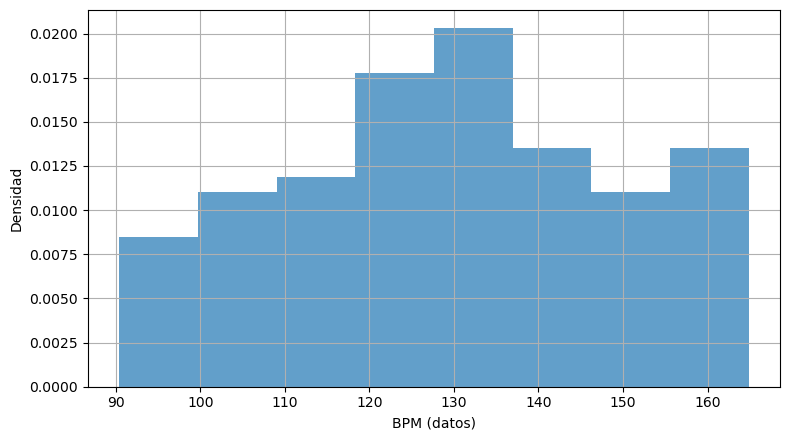

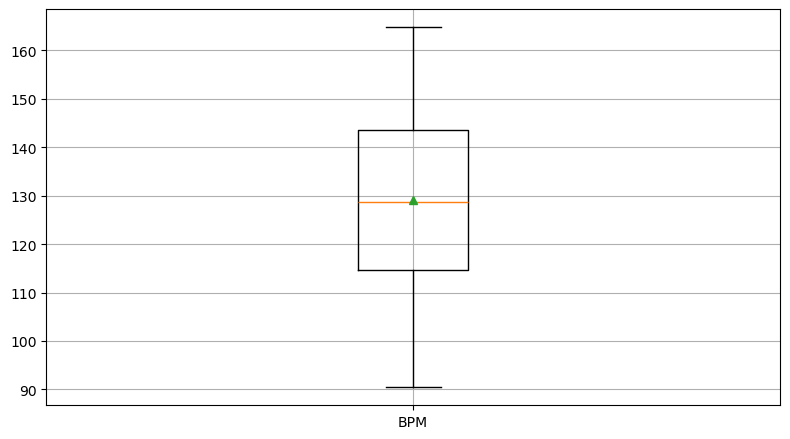

Figuras guardadas en:
 - Documentacion\Avance 1\figures\hist_bpm.png
 - Documentacion\Avance 1\figures\box_bpm.png


In [30]:
#visualización de la distribución de datos

#histograma
fig, ax = plt.subplots()
ax.hist(x, bins="auto", density=True, alpha=0.7)
ax.set_xlabel("BPM (datos)")  # etiqueta del eje X
ax.set_ylabel("Densidad") # etiqueta del eje Y
fig.tight_layout()
hist_path = OUT_DIR / "hist_bpm.png"
fig.savefig(hist_path, dpi=600) # exporta en formato PNG a 600 dpi
plt.show()


fig, ax = plt.subplots()
ax.boxplot(x, vert=True, showmeans=True)
ax.set_xticks([1]); ax.set_xticklabels([COLUMN])
fig.tight_layout()
box_path = OUT_DIR / "box_bpm.png"
fig.savefig(box_path, dpi=600)
plt.show()

print(f"Figuras guardadas en:\n - {hist_path}\n - {box_path}")

In [31]:
#celda para detectar datos atípicos (test de Grubbs)
from math import sqrt
from scipy.stats import t #usada para calcular el valor crítico
#detectar si un valor extremo se considera outlier
def grubbs_critical_value(n: int, alpha: float = 0.05) -> float: #calcula el valor crítico que marca el límite entre "valor normal y valor atípico"
    dof = n - 2 #grados de libertad
    t_alpha = t.ppf(1 - alpha/(2*n), dof) #ajuste bilateral
    return ((n - 1) / sqrt(n)) * sqrt((t_alpha**2) / (dof + t_alpha**2))   # Devuelve Gcrit, umbral de decisión que depende de n y alpha
def grubbs_test_once(x: np.ndarray, alpha: float = 0.05) -> Tuple[bool, int, float]:
    mu, s = np.mean(x), np.std(x, ddof=1)
    diffs = np.abs(x - mu)
    idx = int(np.argmax(diffs))
    G = diffs[idx] / s
    return (G > grubbs_critical_value(x.size, alpha)), idx, G
#ejecuta varias veces el test para aplicar grubs al conjunto completo de datos
def grubbs_iterative(x: np.ndarray, alpha: float = 0.05, max_iters: int = 10):
    x_work = x.copy() # copia del conjunto original (para no modificarlo directamente)
    removed = []  # lista donde se almacenan los atípicos detectados
    for _ in range(max_iters):   # itera hasta alcanzar el límite definido
        ok, idx, G = grubbs_test_once(x_work, alpha=alpha)
        if not ok:   # si no hay más atípicos, detiene el bucle
            break
        removed.append((idx, x_work[idx], G))  # guarda el índice, valor y estadístico G
        x_work = np.delete(x_work, idx)  # elimina el dato atípico del vector
    return x_work, removed # retorna los datos limpios y los removidos


x_clean, removed = grubbs_iterative(x, alpha=0.05, max_iters=50)
print(f"Atípicos removidos: {len(removed)}")
for i,(idx,val,G) in enumerate(removed,1):
    print(f"  {i:02d}) idx_local={idx}, valor={val:.3f}, G={G:.3f}")

Atípicos removidos: 0
